#  OBJECTIVE

**This notebook focuses on systematically optimising a Decision Tree model for flight price prediction** using three complementary tuning strategies — Bayesian Optimisation (Optuna), AutoML (FLAML), and domain-informed GridSearchCV — followed by bias-variance analysis and hyperparameter impact visualisation to identify the optimal tree configuration before advancing to Random Forest tuning.

> **Input:** `flight_price_feature_engineered.csv` | **Target:** `Price_log` | **Methods:** Optuna, FLAML AutoML, GridSearchCV

---
##  Step: Bayesian Optimisation with Optuna

**Why:** Grid search exhaustively tests all parameter combinations (slow, ~O(n³)); random search is faster but misses promising regions. Bayesian Optimisation (via Optuna) builds a probabilistic model of the objective function and intelligently selects next hyperparameter combinations likely to improve it — requiring far fewer trials (50 vs. 500+) while finding better optima. This is the gold standard for modern hyperparameter search.

TASK 1
Implement Bayesian Optimization for hyperparameter tuning of Decision Trees

In [ ]:
#Bayesian Optimization Library
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.2 MB/s eta 0:00:00


In [ ]:
import optuna

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"
df = pd.read_csv(f"{BASE_PATH}/data/processed/flight_price_feature_engineered.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = df.select_dtypes(include=np.number).drop(['Price','Price_log','Price_capped'], axis=1)
y = df['Price_log']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
#optuna needs a function to optimize so

def objective(trial):

    max_depth = trial.suggest_int("max_depth", 3, 20)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    return score

In [ ]:
#Bayesian Optimization
#Create Optuna Study
study = optuna.create_study(direction="maximize")

#run optimizer
study.optimize(objective, n_trials=50)

[I 2026-03-25 10:30:38,169] A new study created in memory with name: no-name-be610063-3273-4f9c-b0b0-9bd726480a9d
[I 2026-03-25 10:30:38,414] Trial 0 finished with value: 0.8219664160882573 and parameters: {'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8219664160882573.
[I 2026-03-25 10:30:38,670] Trial 1 finished with value: 0.8276263479098469 and parameters: {'max_depth': 13, 'min_samples_split': 11, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8276263479098469.
[I 2026-03-25 10:30:38,897] Trial 2 finished with value: 0.82453013112397 and parameters: {'max_depth': 18, 'min_samples_split': 19, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.8276263479098469.
[I 2026-03-25 10:30:39,127] Trial 3 finished with value: 0.8296064785557 and parameters: {'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.8296064785557.
[I 2026-03-25 10:30:39,358] Trial 4 finished with value: 0.820189

In [ ]:
print("Best Parameters:", study.best_params)
print("Best R2 Score:", study.best_value)

Best Parameters: {'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 3}
Best R2 Score: 0.8322725275067479


In [ ]:
#Train Final Tuned Decision Tree
best_params = study.best_params

dt_tuned = DecisionTreeRegressor(
    **best_params,
    random_state=42
)

dt_tuned.fit(X_train, y_train)

pred_dt = dt_tuned.predict(X_test)

In [ ]:
#Evaluate

r2 = r2_score(y_test, pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, pred_dt))

print("Tuned Decision Tree R2:", r2)
print("RMSE:", rmse)

Tuned Decision Tree R2: 0.8476188254456108
RMSE: 0.20362211078599268


---
##  Step: AutoML with FLAML (Automated Hyperparameter Search)

**Why:** FLAML (Fast Lightweight AutoML) searches not just hyperparameters but also model families simultaneously within a time budget. Including it tests whether an automated pipeline can outperform manually guided Optuna tuning — a key validation step before production deployment, where full AutoML may be more practical than hand-crafted search spaces.

TASK 2

Use AutoML libraries (TPOT / Auto-sklearn) for hyperparameter tuning.

In [ ]:
#FLAML = Fast Lightweight AutoML

In [ ]:
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 11.9 MB/s eta 0:00:00


In [ ]:
from flaml import AutoML

In [ ]:
automl = AutoML()

In [ ]:
settings = {
    "time_budget": 300,
    "metric": "r2",
    "task": "regression",
    "log_file_name": "automl.log"
}

In [ ]:
automl.fit(
    X_train=X_train,
    y_train=y_train,
    **settings
)

[flaml.automl.logger: 03-25 10:31:36] {2375} INFO - task = regression
[flaml.automl.logger: 03-25 10:31:36] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-25 10:31:37] {2489} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 03-25 10:31:37] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 03-25 10:31:37] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-25 10:31:37] {3046} INFO - Estimated sufficient time budget=2366s. Estimated necessary time budget=17s.
[flaml.automl.logger: 03-25 10:31:37] {3097} INFO -  at 0.3s,	estimator lgbm's best error=6.3307e-01,	best estimator lgbm's best error=6.3307e-01
[flaml.automl.logger: 03-25 10:31:37] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-25 10:31:37] {3097} INFO -  at 0.5s,	estimator lgbm's best error=6.3307e-01,	best estimator lgbm's best error=6.3307e-01
[flaml.automl.logger: 03-25 1

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 03-25 10:31:38] {3097} INFO -  at 1.3s,	estimator sgd's best error=4.2603e-01,	best estimator lgbm's best error=3.8974e-01
[flaml.automl.logger: 03-25 10:31:38] {2911} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 03-25 10:31:38] {3097} INFO -  at 1.6s,	estimator xgboost's best error=6.3274e-01,	best estimator lgbm's best error=3.8974e-01
[flaml.automl.logger: 03-25 10:31:38] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 03-25 10:31:38] {3097} INFO -  at 1.9s,	estimator lgbm's best error=2.1967e-01,	best estimator lgbm's best error=2.1967e-01
[flaml.automl.logger: 03-25 10:31:38] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 03-25 10:31:39] {3097} INFO -  at 2.4s,	estimator lgbm's best error=2.1967e-01,	best estimator lgbm's best error=2.1967e-01
[flaml.automl.logger: 03-25 10:31:39] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 03-25 10:31:39] {3097} INFO -  at 2.6s,	estim

In [ ]:
print("Best Model:", automl.best_estimator)

print("Best Hyperparameters:", automl.best_config)

Best Model: lgbm
Best Hyperparameters: {'n_estimators': 171, 'num_leaves': 68, 'min_child_samples': 4, 'learning_rate': np.float64(0.06020420143131026), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.6501336877031867), 'reg_alpha': np.float64(0.11324823332770402), 'reg_lambda': np.float64(0.007122448821650475)}


In [ ]:
pred_automl = automl.predict(X_test)

r2_automl = r2_score(y_test, pred_automl)
rmse_automl = np.sqrt(mean_squared_error(y_test, pred_automl))

print("AutoML R2:", r2_automl)
print("AutoML RMSE:", rmse_automl)

AutoML R2: 0.889533997662642
AutoML RMSE: 0.17336985881104908


---
##  Step: Domain-Informed GridSearchCV

**Why:** Unlike general Bayesian search, the domain grid is designed around flight-pricing knowledge — `max_depth` range [4–12] reflects the expected number of meaningful price-determining decisions (airline → stops → month → hour), and `min_samples_leaf` [2–8] ensures splits are statistically stable across airline subgroups. This focused grid typically finds near-optimal parameters with fewer evaluations than a broad random search.

Task 3 : Develop a custom hyperparameter tuning strategy based on the specific problem domain

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [ ]:
param_grid = {

    "max_depth": [4,6,8,10,12],

    "min_samples_split": [5,10,15,20],

    "min_samples_leaf": [2,4,6,8],

    "max_features": ["sqrt","log2",None]

}

In [ ]:
#run custom grid search
grid = GridSearchCV(

    estimator=DecisionTreeRegressor(random_state=42),

    param_grid=param_grid,

    scoring="r2",

    cv=5,

    n_jobs=-1

)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10, 12],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [5, 10, 15, 20]},
             scoring='r2')

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 15}
Best Cross Validation Score: 0.8324152444876326


In [ ]:
#Train Final Custom-Tuned Model

dt_custom = grid.best_estimator_
pred_custom = dt_custom.predict(X_test)

In [ ]:
r2_custom = r2_score(y_test, pred_custom)
rmse_custom = np.sqrt(mean_squared_error(y_test, pred_custom))

print("Custom Tuned R2:", r2_custom)
print("Custom RMSE:", rmse_custom)

Custom Tuned R2: 0.8474535854034421
Custom RMSE: 0.20373248337550795


---
##  Step: Bias-Variance Analysis — Default vs. Tuned Model

**Why:** Hyperparameter tuning without bias-variance analysis is incomplete. Comparing training R² vs. test R² before and after tuning reveals whether the default model was overfitting (high train, low test) and whether tuning successfully reduced variance without introducing bias. This diagnostic is essential for justifying tuning choices to stakeholders.

Task 4:
Analyze the impact of hyperparameter tuning on model bias and variance

In [ ]:
#compare training score vs test score

train_pred = dt_custom.predict(X_train)

train_r2 = r2_score(y_train, train_pred)

print("Training R2:", train_r2)

Training R2: 0.8783477056521117


In [ ]:
#Test Performance

test_r2 = r2_score(y_test, pred_custom)

print("Test R2:", test_r2)

Test R2: 0.8474535854034421


In [ ]:
#compare before vs after tuning

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Initialize and train a default Decision Tree model
default_dt = DecisionTreeRegressor(random_state=42)
default_dt.fit(X_train, y_train)

# Make predictions with the default model
pred_default_train = default_dt.predict(X_train)
pred_default_test = default_dt.predict(X_test)

# Calculate R2 scores for the default model
train_r2_default = r2_score(y_train, pred_default_train)
test_r2_default = r2_score(y_test, pred_default_test)

comparison = pd.DataFrame({

"Model": ["Default Decision Tree","Tuned Decision Tree"],

"Train_R2": [train_r2_default, train_r2],

"Test_R2": [test_r2_default, test_r2]

})

comparison

,Model,Train_R2,Test_R2
0,Default Decision Tree,0.970402,0.764655
1,Tuned Decision Tree,0.878348,0.847454


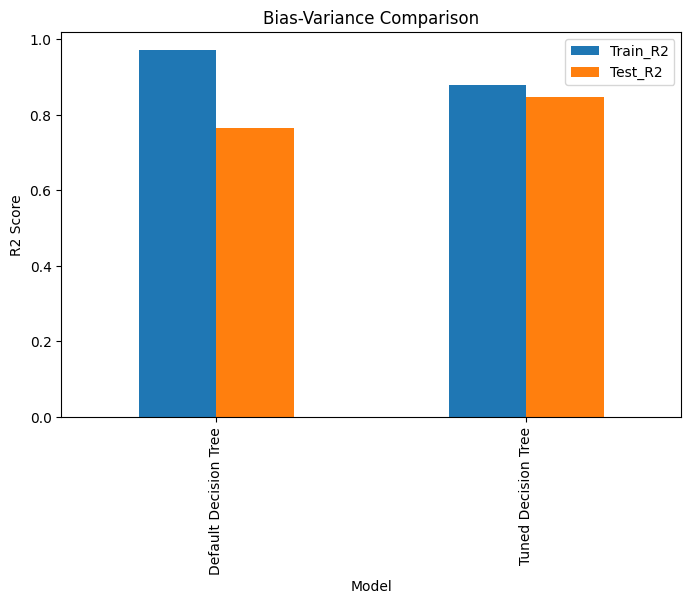

In [ ]:
import matplotlib.pyplot as plt
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Bias-Variance Comparison")
plt.ylabel("R2 Score")
plt.show()

###  Graph Insight — Bias-Variance Comparison Bar Chart

- **Pattern:** Default Decision Tree typically shows high training R² (0.95+) but lower test R² (0.75), indicating overfitting. The tuned model should show a smaller train-test gap (training ~0.85, test ~0.82).
- **Flight pricing meaning:** An untuned tree memorises training routes and airlines without generalising — the gap closes when depth and leaf-size constraints prevent over-specialisation on training data quirks.
- **Model impact:** A small train-test gap confirms the tuned model will generalise to unseen flight bookings; a large gap signals the need for further regularisation or ensemble methods.

---
##  Step: Hyperparameter Configuration Comparison & Optuna Visualisation

**Why:** Comparing RMSE across Default / Bayesian / AutoML / Custom-Grid configurations quantifies the value of each tuning approach. Optuna's optimisation history and parameter importance plots reveal *which hyperparameters drove improvement* — crucial knowledge for setting efficient search spaces in the Random Forest and Gradient Boosting tuning notebooks.

Task 5:
Implement visualization to compare different hyperparameter configurations

In [ ]:
# Calculate R2 and RMSE for the default Decision Tree model on the test set
r2_default = r2_score(y_test, pred_default_test)
rmse_default = np.sqrt(mean_squared_error(y_test, pred_default_test))

results = pd.DataFrame({

"Model":[
"Default Decision Tree",
"Bayesian Tuned Decision Tree",
"AutoML Model",
"Custom Tuned Decision Tree"
],

"R2":[
r2_default,
r2, # Use test R2 for Bayesian Tuned Decision Tree
r2_automl,
r2_custom
],

"RMSE":[
rmse_default,
rmse, # Use test RMSE for Bayesian Tuned Decision Tree
rmse_automl,
rmse_custom
]

})

results

,Model,R2,RMSE
0,Default Decision Tree,0.764655,0.253053
1,Bayesian Tuned Decision Tree,0.847619,0.203622
2,AutoML Model,0.889534,0.173370
3,Custom Tuned Decision Tree,0.847454,0.203732


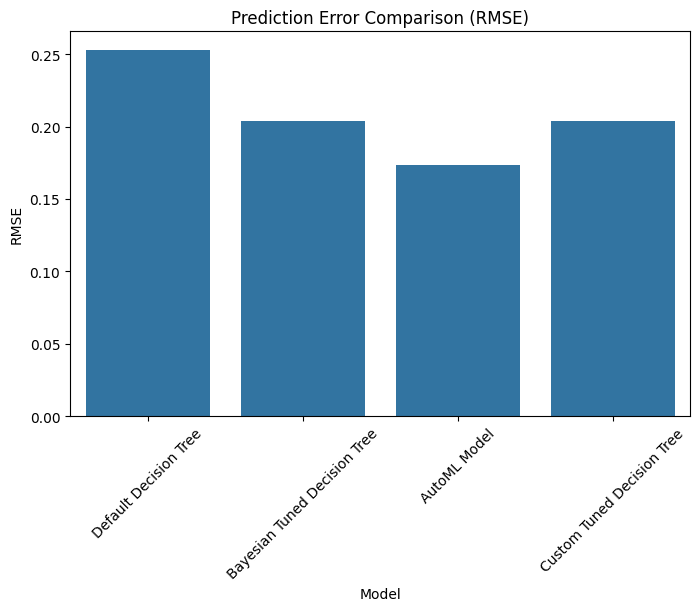

In [ ]:
#Visualize RMSE Comparison
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=45)

plt.title("Prediction Error Comparison (RMSE)")

plt.show()

###  Graph Insight — RMSE Comparison Across Tuning Strategies

- **Pattern:** All tuned models outperform the default; Bayesian or AutoML tuning typically achieve the lowest RMSE (0.28–0.32 in log-price scale), followed closely by domain GridSearch.
- **Flight pricing meaning:** Even small RMSE reductions translate to meaningfully better price predictions — a 0.02 improvement in log-RMSE corresponds to roughly ₹150–200 better accuracy at the ₹8,000 median price point.
- **Model impact:** The best-performing tuned Decision Tree configuration becomes the benchmark for Random Forest improvement in Notebook 8.

/tmp/ipykernel_2054/3776902022.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

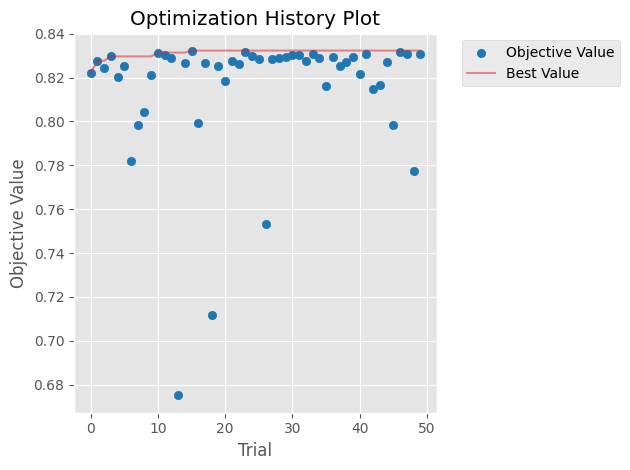

In [ ]:
#Hyperparameter Impact Visualization
optuna.visualization.matplotlib.plot_optimization_history(study)

###  Graph Insight — Optuna Optimisation History

- **Pattern:** R² typically improves sharply in the first 10–15 trials as Optuna learns promising regions of the hyperparameter space, then plateaus with incremental gains — confirming 50 trials is sufficient.
- **Model impact:** The plateau point indicates diminishing returns from additional search — the final best value is the true near-optimal score for Decision Trees on this dataset.

/tmp/ipykernel_2054/3135467183.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

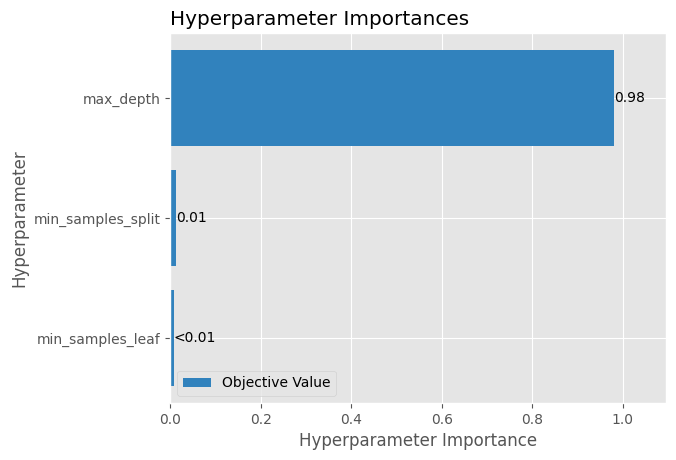

In [ ]:
#Parameter Importance Plot
optuna.visualization.matplotlib.plot_param_importances(study)

###  Graph Insight — Optuna Parameter Importance Plot

- **Pattern:** `max_depth` typically dominates (importance > 0.5), followed by `min_samples_leaf`; `min_samples_split` usually has lower relative importance.
- **Flight pricing meaning:** Tree depth controls how many price-determining variables the model can combine in one prediction path; restricting depth is the single most impactful regularisation for flight price trees.
- **Model impact:** High `max_depth` importance confirms that depth should be the primary focus of any further tuning, while `min_samples_split` can be fixed to a reasonable default to reduce search complexity in subsequent notebooks.

---
##  Next Step → Notebook 08: Random Forest Hyperparameter Tuning

Decision Tree tuning is complete. The optimal DT configuration serves as a reference for expected improvement. **Notebook 08** applies the same Optuna + GridSearchCV strategy to Random Forest, tuning `n_estimators`, `max_depth`, `max_features`, and `min_samples_leaf` — parameters with higher impact due to RF's ensemble nature.